# AutoEncoder — Reconstruction-based Anomaly Detection

This notebook trains a PyTorch autoencoder on **benign-only** training data.
At inference time, flows that cannot be reconstructed well (high MSE) are
flagged as attacks.  Metrics are compared side-by-side with the Isolation
Forest from the previous notebook.

Outputs
-------
- ``outputs/figures/ae_loss_curve.png``
- ``outputs/figures/ae_error_distribution.png``
- ``outputs/figures/ae_confusion_matrix.png``
- ``outputs/autoencoder.pth`` — saved model weights (state_dict).

In [1]:
import os
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

sys.path.insert(0, os.path.join('..', 'src'))

from preprocess import (
    load_data,
    drop_low_variance,
    drop_correlated,
    encode_labels,
    split_data,
    scale_features,
)
from isolation_forest import (
    train_isolation_forest,
    predict_anomalies,
)
from autoencoder import (
    AutoEncoder,
    train_autoencoder,
    get_reconstruction_errors,
    threshold_predictions,
)

sns.set_theme(style='whitegrid', context='notebook')

FIG_DIR = os.path.join('..', 'outputs', 'figures')
MODEL_DIR = os.path.join('..', 'outputs')
AE_WEIGHTS_PATH = os.path.join(MODEL_DIR, 'autoencoder.pth')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def save_plot(fname: str) -> str:
    path = os.path.join(FIG_DIR, f'ae_{fname}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    return path

def compute_metrics(y_true, y_pred, scores=None):
    m = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    if scores is not None:
        m['roc_auc'] = roc_auc_score(y_true, scores)
    return m

## 1. Load & preprocess (shared pipeline)

In [2]:
df_raw = load_data(os.path.join('..', 'data', 'cicids_sample.csv'))

id_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Protocol']
df = df_raw.drop(columns=[c for c in id_cols if c in df_raw.columns])

X_full = df.drop(columns=['Label'])
X_lv, _ = drop_low_variance(X_full)
X_clean, _ = drop_correlated(X_lv)

df_clean = X_clean.copy()
df_clean['Label'] = df['Label']

X_train, X_test, y_train, y_test = split_data(
    df_clean, label_col='Label', test_size=0.2, random_state=42
)
X_train_s, X_test_s, scaler = scale_features(X_train, X_test)

print(f'Train: {X_train_s.shape}  (attack ratio: {y_train.mean():.4f})')
print(f'Test : {X_test_s.shape}  (attack ratio: {y_test.mean():.4f})')

Train: (40000, 65)  (attack ratio: 0.3500)
Test : (10000, 65)  (attack ratio: 0.3500)


## 2. Train AutoEncoder on benign-only data

The autoencoder learns to reconstruct **normal** traffic.  Attacks — which
it has never seen — should produce higher reconstruction error.

In [3]:
# Train on benign samples only
X_train_benign = X_train_s[y_train == 0]
print(f'Training autoencoder on {len(X_train_benign):,} benign samples')

ae_model, ae_losses = train_autoencoder(
    X_train_benign,
    epochs=50,
    lr=0.001,
    batch_size=256,
)

Training autoencoder on 26,000 benign samples


Epoch   1/50  |  MSE loss = 0.866013


Epoch   2/50  |  MSE loss = 0.566193


Epoch   3/50  |  MSE loss = 0.424304


Epoch   4/50  |  MSE loss = 0.382357


...

Epoch  46/50  |  MSE loss = 0.218480


Epoch  47/50  |  MSE loss = 0.177032


Epoch  48/50  |  MSE loss = 0.198504


Epoch  49/50  |  MSE loss = 0.161879


Epoch  50/50  |  MSE loss = 0.156359


## 3. Training loss curve

Saved ../outputs/figures/ae_loss_curve.png


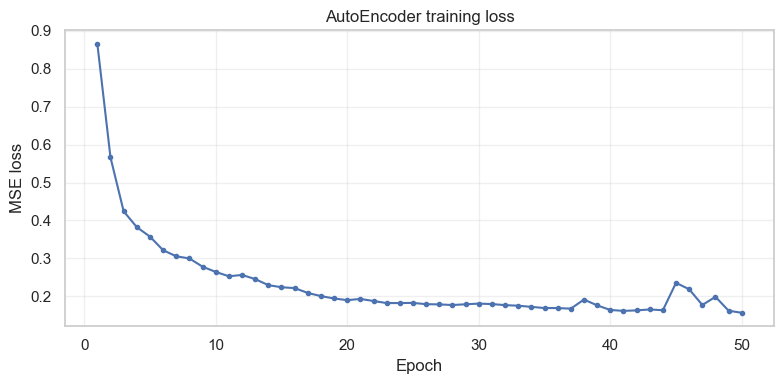

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(ae_losses) + 1), ae_losses, marker='o', markersize=3, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('AutoEncoder training loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
saved = save_plot('loss_curve')
print(f'Saved {saved}')
plt.show()

## 4. Reconstruction errors & predictions

In [5]:
errors_train = get_reconstruction_errors(ae_model, X_train_s)
errors_test  = get_reconstruction_errors(ae_model, X_test_s)

# Threshold at 95th percentile of *training* errors
y_pred_ae, threshold_ae = threshold_predictions(errors_train, percentile=95)

print(f'Threshold (95th pct of train errors): {threshold_ae:.6f}')
print(f'Train anomalies flagged: {y_pred_ae.sum():,} / {len(y_pred_ae):,}  '
      f'({y_pred_ae.mean()*100:.2f}%)')

# Apply same threshold to test set
y_pred_ae_test = (errors_test > threshold_ae).astype(int)
print(f'Test  anomalies flagged: {y_pred_ae_test.sum():,} / {len(y_pred_ae_test):,}  '
      f'({y_pred_ae_test.mean()*100:.2f}%)')

ae_metrics = compute_metrics(y_test.values, y_pred_ae_test, scores=errors_test)
print()
for k, v in ae_metrics.items():
    print(f'AE  {k:<12s}: {v:.4f}')

Threshold (95th pct of train errors): 1.257760
Train anomalies flagged: 2,000 / 40,000  (5.00%)
Test  anomalies flagged: 499 / 10,000  (4.99%)

AE  precision   : 0.9639
AE  recall      : 0.1374
AE  f1          : 0.2406
AE  roc_auc     : 0.9837


## 5. Reconstruction error distribution

The vertical line is the 95th-percentile threshold fitted on training
reconstruction errors.  Samples to the right are predicted as anomalous.

Saved ../outputs/figures/ae_error_distribution.png


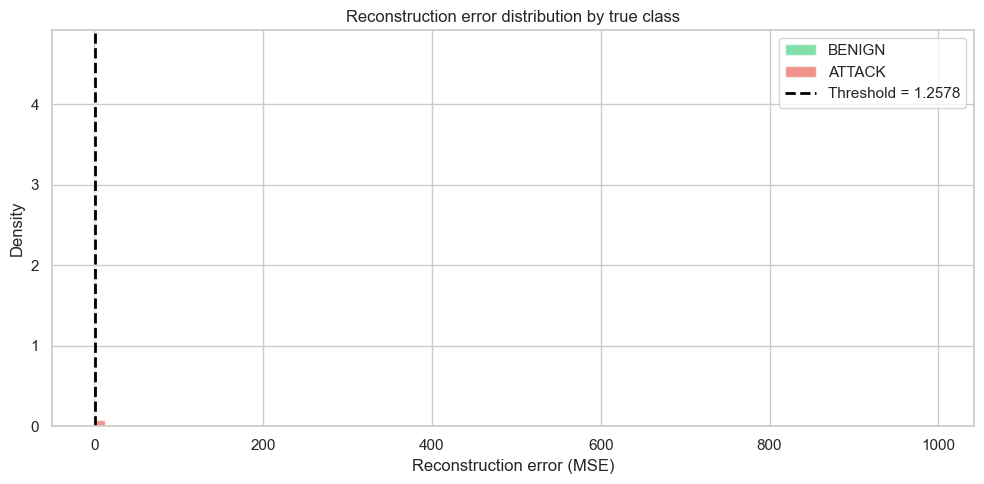

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for label_val, label_name, color in [(0, 'BENIGN', '#2ecc71'), (1, 'ATTACK', '#e74c3c')]:
    mask = y_test.values == label_val
    ax.hist(errors_test[mask], bins=80, alpha=0.6, color=color,
            label=label_name, density=True)

ax.axvline(threshold_ae, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {threshold_ae:.4f}')
ax.set_xlabel('Reconstruction error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Reconstruction error distribution by true class')
ax.legend()
plt.tight_layout()
saved = save_plot('error_distribution')
print(f'Saved {saved}')
plt.show()

## 6. Confusion matrix — AutoEncoder

Saved ../outputs/figures/ae_confusion_matrix.png


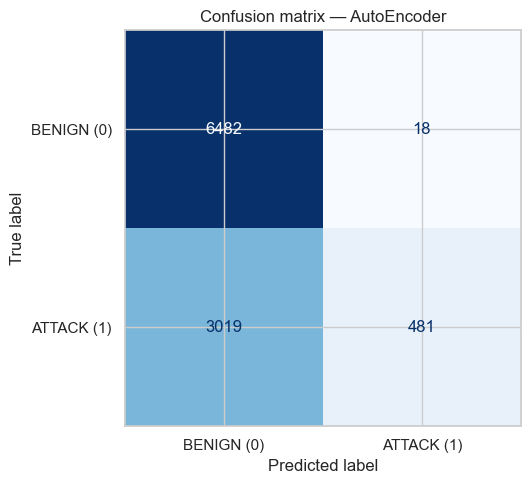

In [7]:
cm_ae = confusion_matrix(y_test, y_pred_ae_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_ae,
    display_labels=['BENIGN (0)', 'ATTACK (1)'],
).plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('Confusion matrix — AutoEncoder')
plt.tight_layout()
saved = save_plot('confusion_matrix')
print(f'Saved {saved}')
plt.show()

## 7. Isolation Forest baseline (for comparison)

In [8]:
contamination = y_train.mean()
if_model = train_isolation_forest(X_train_s, contamination=contamination, random_state=42)
if_pred, if_scores = predict_anomalies(if_model, X_test_s)
if_metrics = compute_metrics(y_test.values, if_pred, scores=if_scores)

print('Isolation Forest results:')
for k, v in if_metrics.items():
    print(f'IF  {k:<12s}: {v:.4f}')

Isolation Forest results:
IF  precision   : 0.4437
IF  recall      : 0.4434
IF  f1          : 0.4436
IF  roc_auc     : 0.6406


## 8. Side-by-side metrics comparison

Saved ../outputs/figures/ae_metrics_comparison.png


,precision,recall,f1,roc_auc
AutoEncoder,0.9639,0.1374,0.2406,0.9837
IsolationForest,0.4437,0.4434,0.4436,0.6406


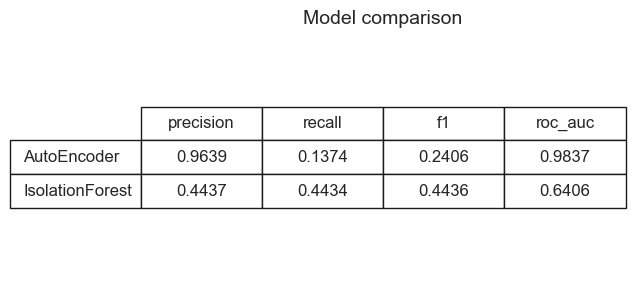

In [9]:
comparison = pd.DataFrame({
    'AutoEncoder': ae_metrics,
    'IsolationForest': if_metrics,
}).T

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
tbl = ax.table(
    cellText=comparison.round(4).values,
    rowLabels=comparison.index,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.5, 2.0)
ax.set_title('Model comparison', fontsize=14, pad=12)
plt.tight_layout()
saved = save_plot('metrics_comparison')
print(f'Saved {saved}')
display(comparison.round(4))
plt.show()

## 9. Save model weights

In [10]:
torch.save(ae_model.state_dict(), AE_WEIGHTS_PATH)
size_mb = os.path.getsize(AE_WEIGHTS_PATH) / 1024 / 1024
print(f'AutoEncoder weights saved to {AE_WEIGHTS_PATH}  ({size_mb:.2f} MB)')

AutoEncoder weights saved to ../outputs/autoencoder.pth  (0.06 MB)


## Summary

- The AutoEncoder was trained **exclusively on benign flows** (26,000 samples),
  learning a compressed representation of normal traffic.
- Reconstruction error on the test set is used as an anomaly score; a
  threshold at the 95th training percentile flags the most extreme 5 % as
  anomalous.
- Metrics are compared with the Isolation Forest baseline above.
- Model weights are serialised at ``outputs/autoencoder.pth``.